# 涨停因子研究

本 Notebook 研究「涨停触及」因子的预测能力：
- **因子定义**：当天最高价 ≥ 理论涨停价（前收盘价 × 1.1）
- **研究问题**：当天涨停的股票，次日是否有超额收益？
- **分析方法**：截面 IC / Rank IC（每个交易日分别计算因子与次日收益的相关性）

**数据**：Tushare Pro 全市场日线，按交易日批量拉取

In [1]:
import os
import sys
import time
sys.path.insert(0, '/app')

import polars as pl
import pandas as pd
import numpy as np
import tushare as ts
from tqdm.notebook import tqdm

START_DATE = '20250301'
END_DATE   = '20260301'

ts.set_token(os.environ['TUSHARE_TOKEN'])
pro = ts.pro_api()
print('Tushare 初始化完成')

Tushare 初始化完成


## 1. 获取交易日历

用 `000001.SZ` 的日线数据推导交易日列表（`trade_cal` 接口需要更高权限）。

In [3]:
# trade_cal requires higher Tushare permission.
# Derive trading dates from a single liquid stock instead.
cal = pro.daily(ts_code='000001.SZ', start_date=START_DATE, end_date=END_DATE, fields='trade_date')
trade_dates = sorted(cal['trade_date'].tolist())
print(f'交易日数: {len(trade_dates)}  ({trade_dates[0]} ~ {trade_dates[-1]})')

交易日数: 241  (20250303 ~ 20260227)


## 2. 检查 DB / 拉取缺失数据 / 读取

流程：
1. 查询 `market.daily` 中已有的交易日 → 找出缺失日期
2. 仅对缺失日期调用 Tushare，写入 DB（幂等）
3. 从 DB 读取全量数据，计算 `prev_close = close.shift(1)`

> `pre_close` 不在 `market.daily` 表结构中，通过排序后 `shift(1)` 得到。
> `is_st` 单独从 `stock_basic` 获取并 join。

In [6]:
from sqlalchemy import text
from app.utils.db import get_engine
from app.data_pipeline.fetch_daily import upsert_daily

engine = get_engine()

# ── 1. 查询 DB 已有的交易日 ───────────────────────────────────
with engine.connect() as conn:
    rows = conn.execute(text("""
        SELECT DISTINCT TO_CHAR(time AT TIME ZONE 'UTC', 'YYYYMMDD')
        FROM market.daily
        WHERE time >= :start AND time < :end
    """), {'start': '2025-03-01', 'end': '2026-03-02'}).fetchall()

existing_dates = {row[0] for row in rows}
missing_dates  = sorted(d for d in trade_dates if d not in existing_dates)
print(f'DB 已有 {len(existing_dates)} 个交易日，需拉取 {len(missing_dates)} 个缺失日期')

# ── 2. 拉取缺失日期并写入 DB ─────────────────────────────────
FETCH_FIELDS = 'ts_code,trade_date,open,high,low,close,pct_chg,vol,amount'

if missing_dates:
    for date in tqdm(missing_dates, desc='拉取并写入 DB'):
        try:
            df_day = pro.daily(trade_date=date, fields=FETCH_FIELDS)
            if df_day is None or df_day.empty:
                continue
            df_pl = (
                pl.from_pandas(df_day)
                .rename({'ts_code': 'symbol', 'trade_date': 'time',
                         'pct_chg': 'pct_change', 'vol': 'volume'})
                .with_columns(
                    pl.col('time').str.strptime(pl.Date, '%Y%m%d').cast(pl.Datetime('us', 'UTC'))
                )
                .with_columns([
                    pl.col('open').cast(pl.Float64),
                    pl.col('high').cast(pl.Float64),
                    pl.col('low').cast(pl.Float64),
                    pl.col('close').cast(pl.Float64),
                    pl.col('pct_change').cast(pl.Float64),
                    pl.col('volume').cast(pl.Int64),
                    pl.col('amount').cast(pl.Float64),
                ])
                .select(['time', 'symbol', 'open', 'high', 'low', 'close',
                         'volume', 'amount', 'pct_change'])
            )
            upsert_daily(df_pl)
        except Exception as e:
            print(f'  {date} 失败: {e}')
        time.sleep(1.25)
    print('写入完成')
else:
    print('DB 数据完整，跳过拉取')

# ── 3. 从 DB 读取全量数据 ─────────────────────────────────────
with engine.connect() as conn:
    rows = conn.execute(text("""
        SELECT time, symbol,
               open::float, high::float, low::float, close::float,
               pct_change::float
        FROM market.daily
        WHERE time >= '2025-03-01' AND time < '2026-03-02'
        ORDER BY symbol, time
    """)).fetchall()

df_raw = pl.DataFrame(
    rows,
    schema=['time', 'symbol', 'open', 'high', 'low', 'close', 'pct_change'],
    orient='row',
)

# ── 4. 计算 prev_close = 上一交易日收盘价 ────────────────────
df_raw = df_raw.with_columns(
    pl.col('close').shift(1).over('symbol').alias('prev_close')
)

# ── 5. 获取 is_st 标记 ────────────────────────────────────────
try:
    st_pd = pro.stock_basic(fields='ts_code,is_st')
    df_st = pl.from_pandas(st_pd).rename({'ts_code': 'symbol'})
    df_raw = df_raw.join(df_st, on='symbol', how='left').with_columns(
        pl.col('is_st').fill_null(0)
    )
except Exception as e:
    print(f'⚠️  is_st 获取失败（{e}），ST 股将不被过滤')
    df_raw = df_raw.with_columns(pl.lit(0).alias('is_st'))

print(f'\n原始数据: {len(df_raw):,} 行，股票数量: {df_raw["symbol"].n_unique()}')
df_raw.head(3)

DB 已有 241 个交易日，需拉取 0 个缺失日期
DB 数据完整，跳过拉取
⚠️  is_st 获取失败（抱歉，您每小时最多访问该接口1次，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。），ST 股将不被过滤

原始数据: 1,305,961 行，股票数量: 5511


time,symbol,open,high,low,close,pct_change,prev_close,is_st
"datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64,i32
2025-03-03 00:00:00 UTC,"""000001.SZ""",11.52,11.56,11.45,11.51,-0.1735,null,0
2025-03-04 00:00:00 UTC,"""000001.SZ""",11.47,11.55,11.44,11.51,0.0,11.51,0
2025-03-05 00:00:00 UTC,"""000001.SZ""",11.52,11.67,11.48,11.66,1.3032,11.51,0


## 3. 数据清洗 & 计算涨停因子

过滤规则：
- 排除 ST/\*ST 股票（涨跌幅限制为 ±5%，涨停价计算不同）
- 排除 `pre_close` 为 null 或 0 的行（新股上市首日）
- 排除 `high` 为 null 的停牌行

In [7]:
df = (
    df_raw
    # 过滤 ST 股、停牌（high=null）、新股首日（prev_close=null）
    .filter(
        (pl.col('is_st') == 0) &
        pl.col('prev_close').is_not_null() & (pl.col('prev_close') > 0) &
        pl.col('high').is_not_null()
    )
)

# ── 计算涨停因子 ──────────────────────────────────────────────
# 理论涨停价（四舍五入到分）
df = df.with_columns(
    limit_up_price=(pl.col('prev_close') * 1.1).round(2)
)

# 当天最高价是否触及涨停价
df = df.with_columns(
    is_limit_up=(pl.col('high') >= pl.col('limit_up_price')).cast(pl.Int8)
)

n_limit_up = df.filter(pl.col('is_limit_up') == 1).height
print(f'清洗后: {len(df):,} 行，涨停记录: {n_limit_up:,} ({n_limit_up/len(df)*100:.2f}%)')
df.select(['time', 'symbol', 'prev_close', 'high', 'limit_up_price', 'is_limit_up', 'pct_change']).head(5)

清洗后: 1,300,450 行，涨停记录: 36,130 (2.78%)


time,symbol,prev_close,high,limit_up_price,is_limit_up,pct_change
"datetime[μs, UTC]",str,f64,f64,f64,i8,f64
2025-03-04 00:00:00 UTC,"""000001.SZ""",11.51,11.55,12.66,0,0.0
2025-03-05 00:00:00 UTC,"""000001.SZ""",11.51,11.67,12.66,0,1.3032
2025-03-06 00:00:00 UTC,"""000001.SZ""",11.66,11.7,12.83,0,-0.2573
2025-03-07 00:00:00 UTC,"""000001.SZ""",11.63,11.69,12.79,0,0.3439
2025-03-10 00:00:00 UTC,"""000001.SZ""",11.67,11.67,12.84,0,-0.6855


## 4. 构造次日收益（IC 分析标的）

对每只股票，将 `pct_change` 向前移动一天（`shift(-1).over('symbol')`），得到 `next_ret`。

In [8]:
df = (
    df
    .sort(['symbol', 'time'])
    .with_columns(
        pl.col('pct_change').shift(-1).over('symbol').alias('next_ret')
    )
    .drop_nulls('next_ret')
)

print(f'含 next_ret 的有效行数: {len(df):,}')
print(f'涨停次日收益均值: {df.filter(pl.col("is_limit_up")==1)["next_ret"].mean():.4f}%')
print(f'非涨停次日收益均值: {df.filter(pl.col("is_limit_up")==0)["next_ret"].mean():.4f}%')

含 next_ret 的有效行数: 1,294,939
涨停次日收益均值: 0.7089%
非涨停次日收益均值: 0.1428%


## 5. 截面 IC 分析

**截面 IC**：每个交易日，计算所有股票「涨停因子」与「次日收益」的相关系数。

- **IC (Pearson)**：线性相关，对异常值敏感
- **Rank IC (Spearman)**：基于排名，对非线性和异常值更鲁棒，实践中更常用

| 指标 | 含义 |
|------|------|
| IC mean | 平均预测能力，> 0.02 有一定意义 |
| IC std  | IC 稳定性，越小越好 |
| ICIR    | IC mean / IC std，> 0.5 较好 |
| IC > 0 比例 | 因子方向正确的天数占比 |

In [10]:
# 截面 IC：每日计算
ic_daily = (
    df
    .group_by('time')
    .agg([
        pl.corr('is_limit_up', 'next_ret').alias('ic'),
        pl.corr('is_limit_up', 'next_ret', method='spearman').alias('rank_ic'),
        pl.len().alias('n_stocks'),
    ])
    .sort('time')
    .drop_nulls()
)

ic_mean  = ic_daily['ic'].mean()
ic_std   = ic_daily['ic'].std()
icir     = ic_mean / ic_std if ic_std else 0
ic_pos   = (ic_daily['ic'] > 0).mean()

ric_mean = ic_daily['rank_ic'].mean()
ric_std  = ic_daily['rank_ic'].std()
ricir    = ric_mean / ric_std if ric_std else 0
ric_pos  = (ic_daily['rank_ic'] > 0).mean()

h1, h2 = 'IC (Pearson)', 'Rank IC (Spearman)'
print(f'═══ IC 统计（is_limit_up → next_ret）═══')
print(f'               {h1:>14s}   {h2:>18s}')
print(f'  Mean       {ic_mean:>14.4f}   {ric_mean:>18.4f}')
print(f'  Std        {ic_std:>14.4f}   {ric_std:>18.4f}')
print(f'  ICIR       {icir:>14.4f}   {ricir:>18.4f}')
print(f'  IC > 0     {ic_pos:>13.1%}   {ric_pos:>17.1%}')
print(f'  N days     {len(ic_daily):>14d}')
ic_daily.head()

═══ IC 统计（is_limit_up → next_ret）═══
                 IC (Pearson)   Rank IC (Spearman)
  Mean               0.0311              -0.0114
  Std                0.0734               0.0476
  ICIR               0.4230              -0.2393
  IC > 0             66.1%               41.0%
  N days                239


time,ic,rank_ic,n_stocks
"datetime[μs, UTC]",f64,f64,u32
2025-03-04 00:00:00 UTC,0.066054,0.00062,5380
2025-03-05 00:00:00 UTC,0.026212,-0.027775,5382
2025-03-06 00:00:00 UTC,0.018579,-0.056364,5380
2025-03-07 00:00:00 UTC,-0.021204,-0.050536,5379
2025-03-10 00:00:00 UTC,0.01854,-0.032153,5379


## 6. 滚动 IC 曲线 & 分布

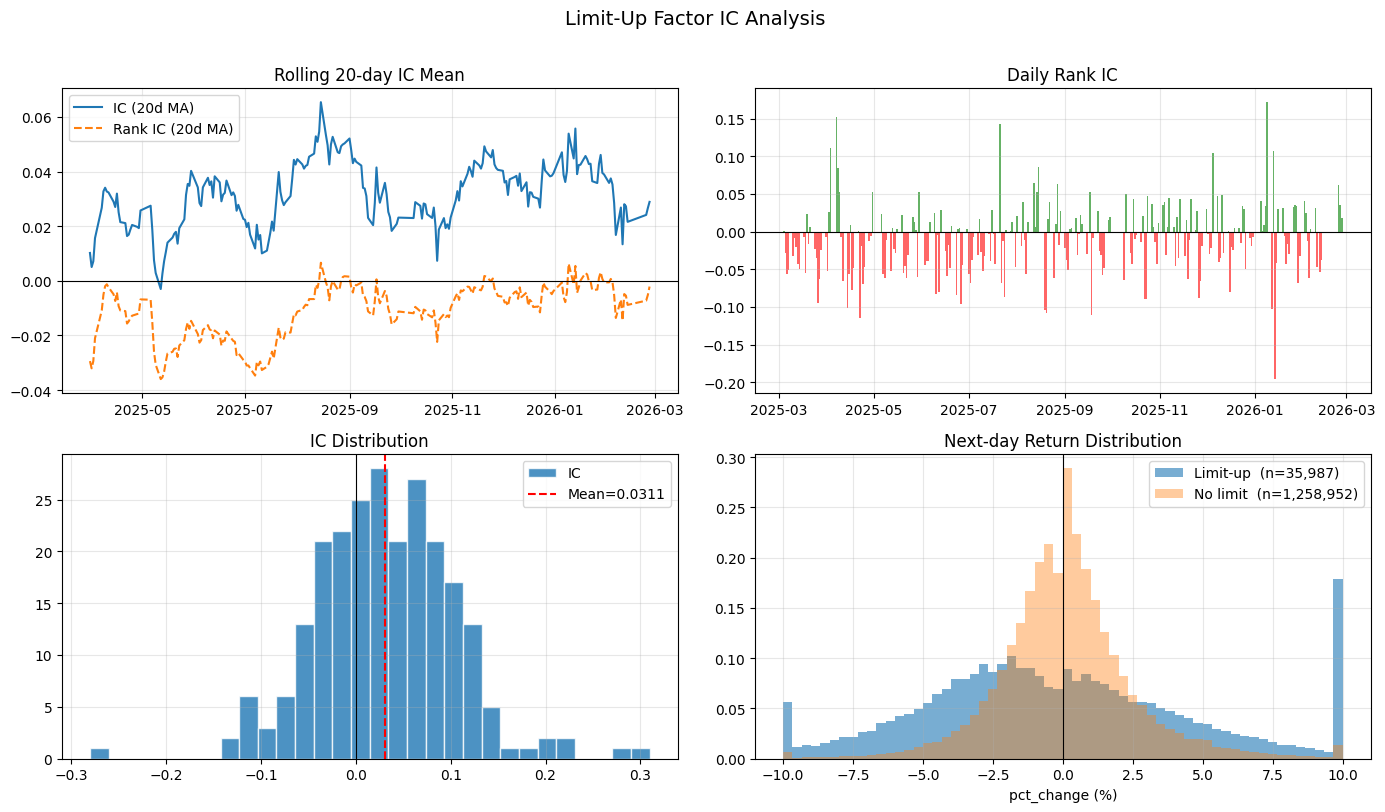

In [11]:
import matplotlib.pyplot as plt

ic_pd = ic_daily.to_pandas().set_index('time')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── 滚动 20 日 IC 均值 ──────────────────────────────────────
rolling_ic = ic_pd['ic'].rolling(20).mean()
rolling_ric = ic_pd['rank_ic'].rolling(20).mean()
axes[0, 0].plot(rolling_ic.index, rolling_ic.values, label='IC (20d MA)')
axes[0, 0].plot(rolling_ric.index, rolling_ric.values, label='Rank IC (20d MA)', linestyle='--')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Rolling 20-day IC Mean')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── IC 逐日柱状图 ────────────────────────────────────────────
colors = ['green' if v >= 0 else 'red' for v in ic_pd['rank_ic']]
axes[0, 1].bar(ic_pd.index, ic_pd['rank_ic'].values, color=colors, alpha=0.6, width=1)
axes[0, 1].axhline(0, color='black', linewidth=0.8)
axes[0, 1].set_title('Daily Rank IC')
axes[0, 1].grid(True, alpha=0.3)

# ── IC 分布直方图 ────────────────────────────────────────────
axes[1, 0].hist(ic_pd['ic'].dropna(), bins=30, edgecolor='white', alpha=0.8, label='IC')
axes[1, 0].axvline(ic_mean, color='red', linestyle='--', label=f'Mean={ic_mean:.4f}')
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_title('IC Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── 涨停次日收益分布 ──────────────────────────────────────────
ret_lu  = df.filter(pl.col('is_limit_up') == 1)['next_ret'].cast(pl.Float64).to_numpy()
ret_nlu = df.filter(pl.col('is_limit_up') == 0)['next_ret'].cast(pl.Float64).to_numpy()
axes[1, 1].hist(ret_lu,  bins=60, alpha=0.6, label=f'Limit-up  (n={len(ret_lu):,})', density=True, range=(-10, 10))
axes[1, 1].hist(ret_nlu, bins=60, alpha=0.4, label=f'No limit  (n={len(ret_nlu):,})', density=True, range=(-10, 10))
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Next-day Return Distribution')
axes[1, 1].set_xlabel('pct_change (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Limit-Up Factor IC Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. 分组收益分析（因子分层）

将 `is_limit_up` 分为两组（涨停 vs 未涨停），对比各组的次日平均收益和胜率。

In [12]:
group_stats = (
    df
    .with_columns(pl.col('next_ret').cast(pl.Float64))
    .group_by('is_limit_up')
    .agg([
        pl.len().alias('count'),
        pl.col('next_ret').mean().alias('mean_ret'),
        pl.col('next_ret').median().alias('median_ret'),
        pl.col('next_ret').std().alias('std_ret'),
        (pl.col('next_ret') > 0).mean().alias('win_rate'),
    ])
    .sort('is_limit_up')
)

print('=== Next-day return by group ===')
print(group_stats)

=== Next-day return by group ===
shape: (2, 6)
┌─────────────┬─────────┬──────────┬────────────┬──────────┬──────────┐
│ is_limit_up ┆ count   ┆ mean_ret ┆ median_ret ┆ std_ret  ┆ win_rate │
│ ---         ┆ ---     ┆ ---      ┆ ---        ┆ ---      ┆ ---      │
│ i8          ┆ u32     ┆ f64      ┆ f64        ┆ f64      ┆ f64      │
╞═════════════╪═════════╪══════════╪════════════╪══════════╪══════════╡
│ 0           ┆ 1258952 ┆ 0.142773 ┆ 0.0        ┆ 2.865366 ┆ 0.495625 │
│ 1           ┆ 35987   ┆ 0.70891  ┆ -0.1792    ┆ 6.373239 ┆ 0.484119 │
└─────────────┴─────────┴──────────┴────────────┴──────────┴──────────┘
